In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/train.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1458644, 11)

Columns: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [ ]:
print("Rows before cleaning", df.shape[0])
df[df.isna().any(axis=1)]
df = df.dropna()  # drop the missing rows
print("Rows after cleaning", df.shape[0])

Rows before cleaning 1458644
Rows after cleaning 1458644


In [ ]:
print("Rows before cleaning", df.shape[0])
df = df[df["passenger_count"] > 0]
print("Rows after cleaning", df.shape[0])

Rows before cleaning 1458644
Rows after cleaning 1458584


In [ ]:
print("Rows before trip_duration outlier removal", df.shape[0])


MIN_DURATION = 60
MAX_DURATION = 4 * 3600

# Filter trips within bounds
df = df[
    (df["trip_duration"] >= MIN_DURATION) &
    (df["trip_duration"] <= MAX_DURATION)
]

# Count after cleaning
print("Rows after trip_duration outlier removal", df.shape[0])


Rows before trip_duration outlier removal 1458584
Rows after trip_duration outlier removal 1447955


In [ ]:
# Count before cleaning
print("Rows before removing high passenger count:", df.shape[0])

# Remove trips with passenger_count > 5
df = df[df["passenger_count"] <= 5]

# Count after cleaning
print("Rows after removing high passenger count:", df.shape[0])


Rows before removing high passenger count: 1447955
Rows after removing high passenger count: 1399917


In [ ]:
print("Rows before filtering coordinates:", df.shape[0])

# Define NYC bounding box
MIN_LAT, MAX_LAT = 40.5, 41.0
MIN_LON, MAX_LON = -74.3, -73.6

# Filter rows where both pickup and dropoff are within the box
df = df[
    (df["pickup_latitude"].between(MIN_LAT, MAX_LAT)) &
    (df["pickup_longitude"].between(MIN_LON, MAX_LON)) &
    (df["dropoff_latitude"].between(MIN_LAT, MAX_LAT)) &
    (df["dropoff_longitude"].between(MIN_LON, MAX_LON))
]

# Count after cleaning
print("Rows after filtering coordinates:", df.shape[0])

Rows before filtering coordinates: 1399917
Rows after filtering coordinates: 1399400


In [ ]:
print("Rows before removing trips with identical start and end:", df.shape[0])

# Remove trips with same pickup and dropoff coordinates
df = df[
    ~(
        (df["pickup_latitude"] == df["dropoff_latitude"]) &
        (df["pickup_longitude"] == df["dropoff_longitude"])
    )
]

# Count after cleaning
print("Rows after removing trips with identical start and end:", df.shape[0])


Rows before removing trips with identical start and end: 1399400
Rows after removing trips with identical start and end: 1395479


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

df["distance_haversine_km"] = haversine_distance(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"]
)
# Constants for NYC
LAT_KM = 111
LON_KM = 85

# Manhattan distance approximation
df["distance_manhattan_km"] = (
    np.abs(df["dropoff_latitude"] - df["pickup_latitude"]) * LAT_KM +
    np.abs(df["dropoff_longitude"] - df["pickup_longitude"]) * LON_KM
)

print(df[["distance_haversine_km", "distance_manhattan_km"]].describe())


       distance_haversine_km  distance_manhattan_km
count           1.395479e+06           1.395479e+06
mean            3.455368e+00           4.480167e+00
std             3.894574e+00           5.201147e+00
min             4.241750e-04           4.234314e-04
25%             1.250921e+00           1.600477e+00
50%             2.113087e+00           2.720921e+00
75%             3.899776e+00           5.043358e+00
max             4.776513e+01           6.780312e+01


In [ ]:
# Haversine speed in km/h
df["speed_haversine_kmh"] = df["distance_haversine_km"] / (df["trip_duration"] / 3600)
# Manhattan speed in km/h
df["speed_manhattan_kmh"] = df["distance_manhattan_km"] / (df["trip_duration"] / 3600)
print(df[["speed_haversine_kmh", "speed_manhattan_kmh"]].describe())


       speed_haversine_kmh  speed_manhattan_kmh
count         1.395479e+06         1.395479e+06
mean          1.444306e+01         1.872812e+01
std           7.687316e+00         1.041352e+01
min           1.190384e-03         1.201541e-03
25%           9.200928e+00         1.164680e+01
50%           1.283922e+01         1.646245e+01
75%           1.786556e+01         2.323505e+01
max           5.837343e+02         8.113339e+02


In [ ]:
MAX_SPEED = 160  # km/h, physical limit for NYC taxi

print("Rows before removing impossible speeds:", df.shape[0])

# Keep only trips with Haversine speed <= MAX_SPEED
df = df[df["speed_haversine_kmh"] <= MAX_SPEED]

print("Rows after removing impossible speeds:", df.shape[0])


Rows before removing impossible speeds: 1395479
Rows after removing impossible speeds: 1395466


In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Pickup hour (0–23)
df["pickup_hour"] = df["pickup_datetime"].dt.hour

# Day of month (1–31)
df["pickup_day"] = df["pickup_datetime"].dt.day

# Day of week (0=Monday, 6=Sunday)
df["pickup_weekday"] = df["pickup_datetime"].dt.weekday

# Month (1–12)
df["pickup_month"] = df["pickup_datetime"].dt.month

df["is_weekend"] = df["pickup_weekday"].apply(lambda x: 1 if x >= 5 else 0)

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_haversine_km,distance_manhattan_km,speed_haversine_kmh,speed_manhattan_kmh,pickup_hour,pickup_day,pickup_weekday,pickup_month,is_weekend
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,1.748741,11.856428,13.836194,17,14,0,3,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,2.443325,9.803659,13.266923,0,12,6,6,1
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,6.385098,8.213604,10.822201,13.921363,11,19,1,1,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1.485498,1.660362,12.465721,13.933110,19,6,2,4,0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1.188588,1.197479,9.836594,9.910173,13,26,5,3,1


In [ ]:
def rush_hour(hour):
    if 7 <= hour <= 10 or 16 <= hour <= 19:
        return 1
    else:
        return 0

df["is_rush_hour"] = df["pickup_hour"].apply(rush_hour)


In [ ]:
df["circuitousness"] = df["distance_manhattan_km"] / df["distance_haversine_km"]
df["circuitousness"].describe()

,circuitousness
count,1.395466e+06
mean,1.289991e+00
std,1.186756e-01
min,9.982470e-01
25%,1.207374e+00
50%,1.331203e+00
75%,1.390182e+00
max,1.421268e+00


EDA

In [ ]:
# Summary statistics for numeric features
numeric_cols = ["trip_duration", "distance_haversine_km", "distance_manhattan_km",
                "speed_haversine_kmh", "speed_manhattan_kmh", "circuitousness"]

df[numeric_cols].describe()


,trip_duration,distance_haversine_km,distance_manhattan_km,speed_haversine_kmh,speed_manhattan_kmh,circuitousness
count,1.395466e+06,1.395466e+06,1.395466e+06,1.395466e+06,1.395466e+06,1.395466e+06
mean,8.417203e+02,3.455270e+00,4.480035e+00,1.444069e+01,1.872494e+01,1.289991e+00
std,6.585309e+02,3.894429e+00,5.200941e+00,7.639119e+00,1.034736e+01,1.186756e-01
min,6.000000e+01,4.241750e-04,4.234314e-04,1.190384e-03,1.201541e-03,9.982470e-01
25%,4.010000e+02,1.250907e+00,1.600468e+00,9.200918e+00,1.164672e+01,1.207374e+00
50%,6.650000e+02,2.113065e+00,2.720898e+00,1.283918e+01,1.646238e+01,1.331203e+00
75%,1.076000e+03,3.899698e+00,5.043262e+00,1.786544e+01,2.323482e+01,1.390182e+00
max,1.424300e+04,4.776513e+01,6.780312e+01,1.535591e+02,2.079494e+02,1.421268e+00


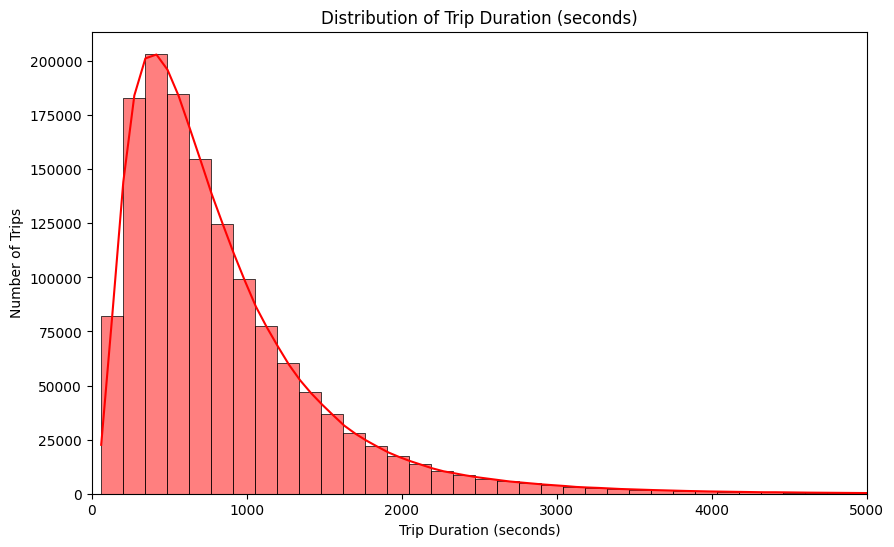

In [ ]:
plt.figure(figsize=(10,6))

# Histogram + KDE
sns.histplot(df["trip_duration"], bins=100, kde=True, color="red", edgecolor="black")

plt.title("Distribution of Trip Duration (seconds)")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Number of Trips")
plt.xlim(0, 5000)  # zoom in to ignore extreme outliers for better visualization
plt.show()


Text(0.5, 1.0, 'Spatial Heatmap of Circuitousness')

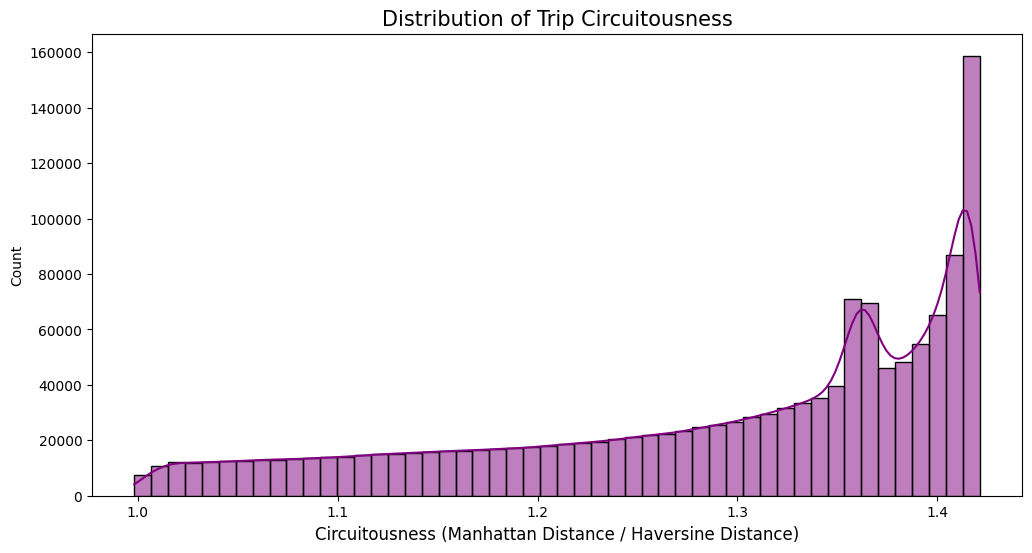

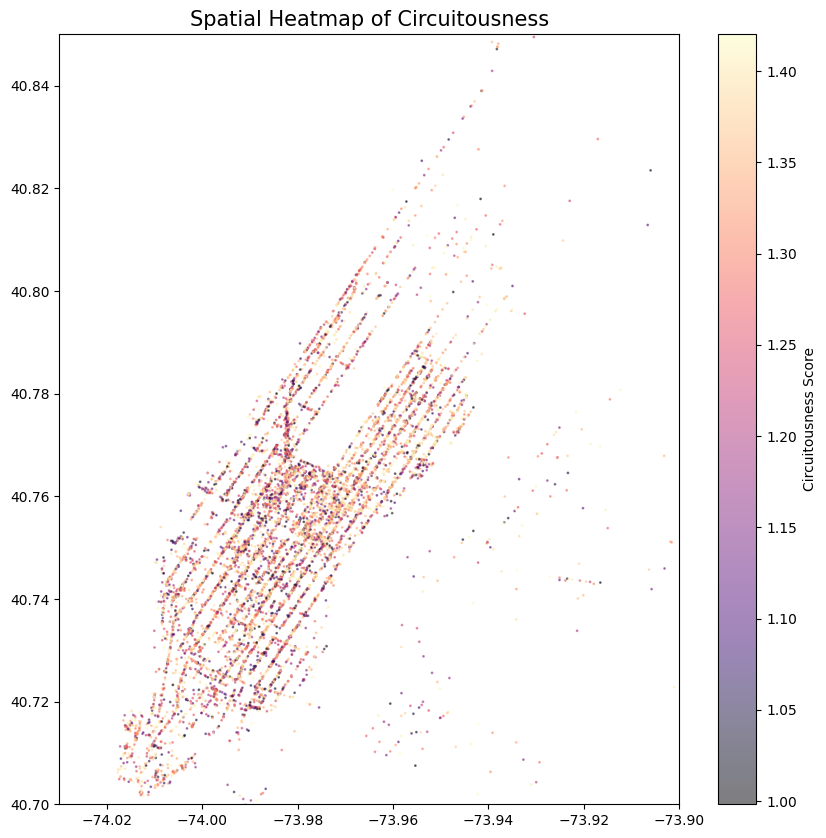

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['circuitousness'], bins=50, kde=True, color='purple')
plt.title('Distribution of Trip Circuitousness', fontsize=15)
plt.xlabel('Circuitousness (Manhattan Distance / Haversine Distance)', fontsize=12)
plt.savefig('circuitousness_dist.png')

sample_df = df.sample(n=10000, random_state=42)
plt.figure(figsize=(10, 10))
plt.scatter(sample_df['pickup_longitude'], sample_df['pickup_latitude'],
            c=sample_df['circuitousness'], cmap='magma', s=1, alpha=0.5)
plt.colorbar(label='Circuitousness Score')
plt.xlim([-74.03, -73.90])
plt.ylim([40.70, 40.85])

plt.title('Spatial Heatmap of Circuitousness', fontsize=15)

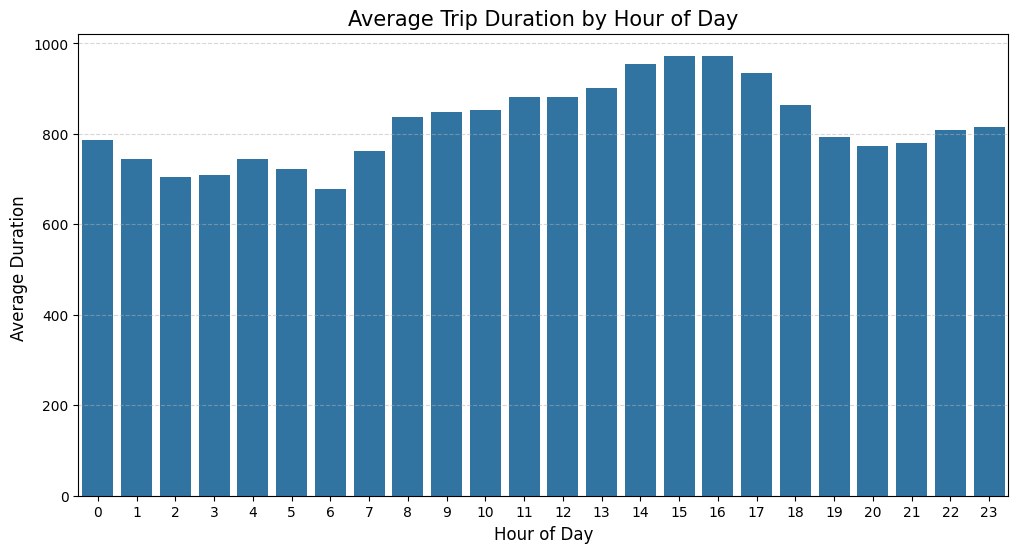

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='pickup_hour', y='trip_duration', errorbar=None)
plt.title('Average Trip Duration by Hour of Day', fontsize=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Duration ', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


/tmp/ipykernel_393/995256310.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pickup_month', y='trip_duration', palette='magma', errorbar=None)


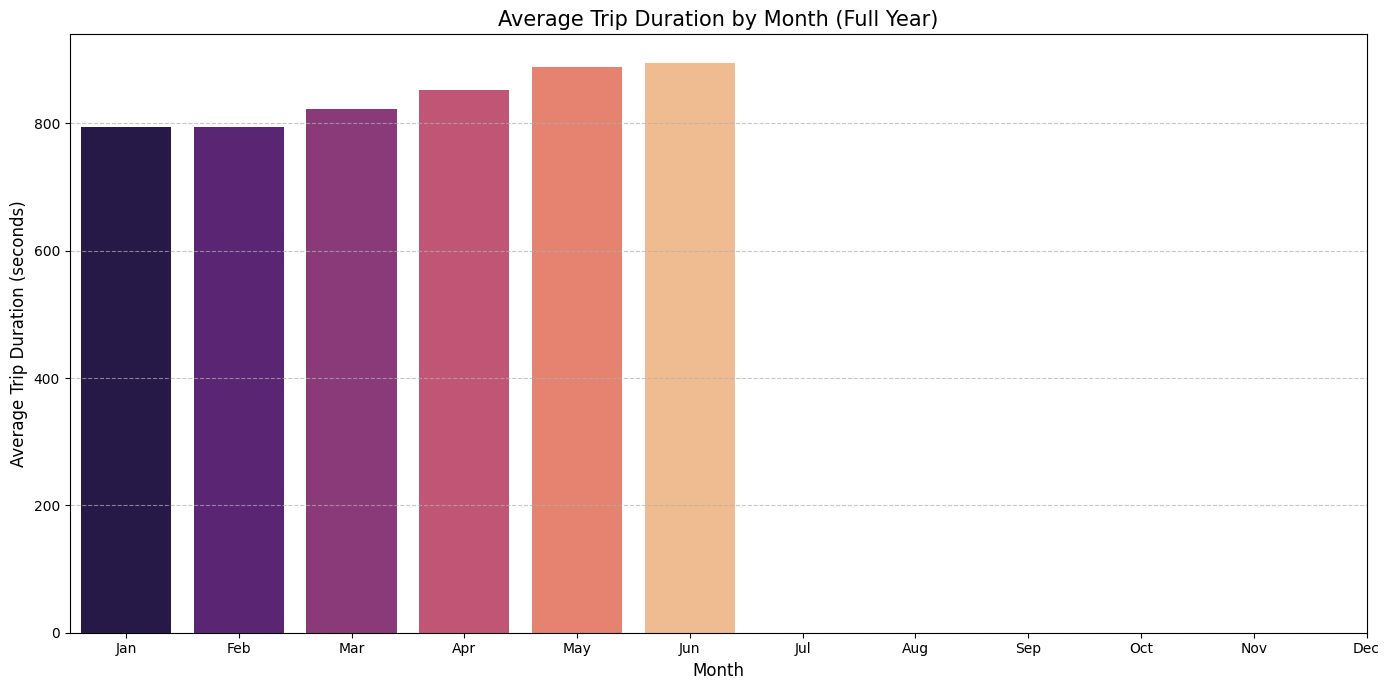

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df now contains the full year of data
plt.figure(figsize=(14, 7))

# Plotting average duration by month
sns.barplot(data=df, x='pickup_month', y='trip_duration', palette='magma', errorbar=None)

# Formatting the plot
plt.title('Average Trip Duration by Month (Full Year)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Trip Duration (seconds)', fontsize=12)

# Set labels for all months
plt.xticks(ticks=range(0, 12),
           labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_393/2064594773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='passenger_count', y='trip_duration', showfliers=False, palette='Set2')
/tmp/ipykernel_393/2064594773.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='passenger_count', y='speed_haversine_kmh', showfliers=False, palette='Set2')


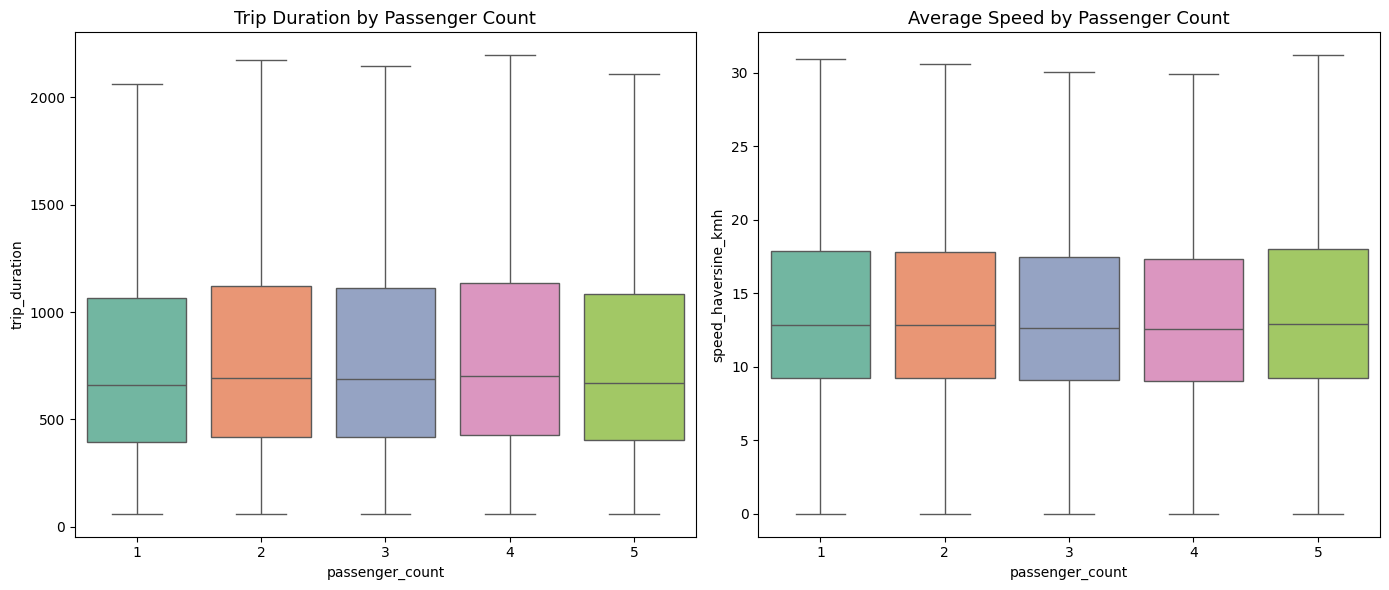

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='passenger_count', y='trip_duration', showfliers=False, palette='Set2')
plt.title('Trip Duration by Passenger Count', fontsize=13)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='passenger_count', y='speed_haversine_kmh', showfliers=False, palette='Set2')
plt.title('Average Speed by Passenger Count', fontsize=13)

plt.tight_layout()

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['date'] = df['pickup_datetime'].dt.date
weather_dates = pd.DataFrame({
    "date": df['date'].unique()
})
weather_dates['date'] = pd.to_datetime(weather_dates['date'])
weather_dates = weather_dates.sort_values('date')
import requests

def fetch_weather(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": 40.7128,
        "longitude": -74.0060,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_mean",
            "precipitation_sum",
            "rain_sum",
            "snowfall_sum",
            "windspeed_10m_max"
        ],
        "timezone": "America/New_York"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

In [ ]:
start_date = weather_dates['date'].min().strftime("%Y-%m-%d")
end_date   = weather_dates['date'].max().strftime("%Y-%m-%d")

weather_raw = fetch_weather(start_date, end_date)
weather_df = pd.DataFrame({
    "date": pd.to_datetime(weather_raw["daily"]["time"]),
    "temp_c": weather_raw["daily"]["temperature_2m_mean"],
    "precip_mm": weather_raw["daily"]["precipitation_sum"],
    "rain_mm": weather_raw["daily"]["rain_sum"],
    "snowfall_cm": weather_raw["daily"]["snowfall_sum"],
    "wind_kmh": weather_raw["daily"]["windspeed_10m_max"]
})
weather_df.head()


,date,temp_c,precip_mm,rain_mm,snowfall_cm,wind_kmh
0,2016-01-01,3.2,0.0,0.0,0.0,21.1
1,2016-01-02,1.0,0.0,0.0,0.0,15.5
2,2016-01-03,1.9,0.0,0.0,0.0,19.1
3,2016-01-04,-2.4,0.0,0.0,0.0,26.3
4,2016-01-05,-6.0,0.0,0.0,0.0,25.7


In [ ]:
df['date'] = pd.to_datetime(df['date'])
weather_df['date'] = pd.to_datetime(weather_df['date'])
rows_before = len(df)

df = df.merge(
    weather_df,
    on='date',
    how='left'
)

rows_after = len(df)

print("Rows before merge:", rows_before)
print("Rows after merge:", rows_after)

Rows before merge: 1395466
Rows after merge: 1395466


In [ ]:
# Any missing weather rows?
df[['temp_c', 'precip_mm', 'snowfall_cm']].isna().sum()

# Unique weather days
df['date'].nunique(), weather_df['date'].nunique()


(182, 182)

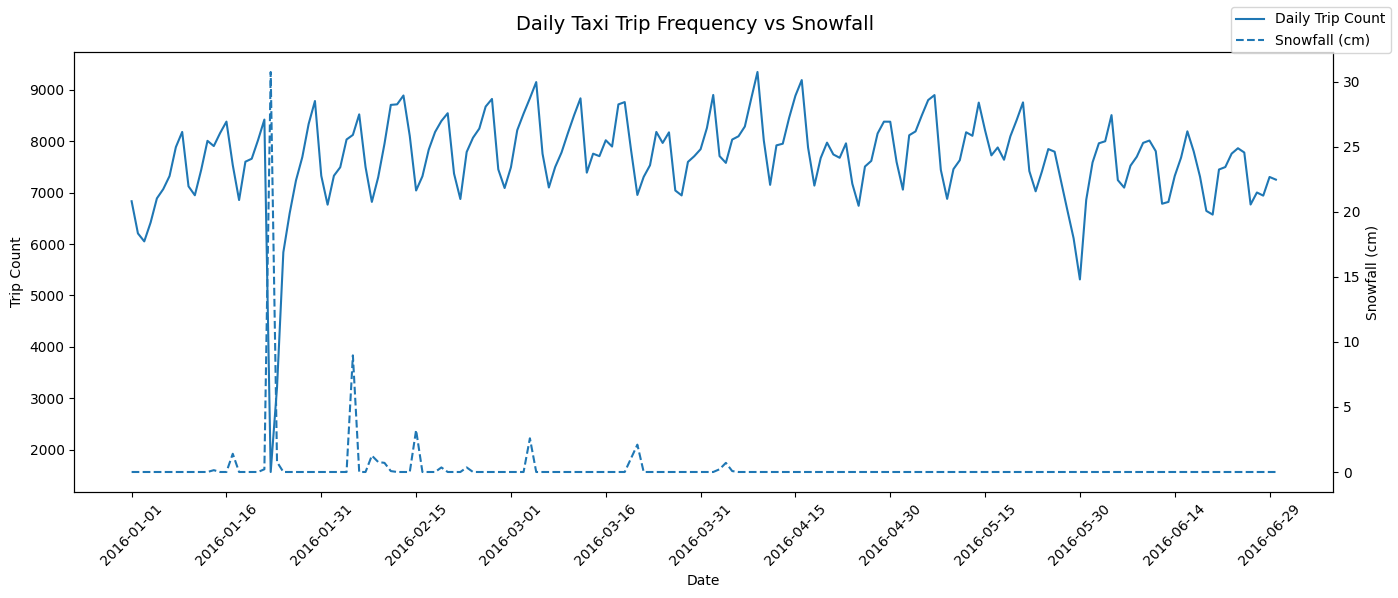

In [ ]:
df['date'] = df['pickup_datetime'].dt.date

# Daily aggregation
daily_weather = (
    df
    .groupby('date')
    .agg(
        trip_count=('id', 'count'),
        snowfall_cm=('snowfall_cm', 'mean')
    )
    .reset_index()
)

daily_weather['date'] = pd.to_datetime(daily_weather['date'])
daily_weather.head()
fig, ax1 = plt.subplots(figsize=(14, 6))

# Trip count
ax1.plot(
    daily_weather['date'],
    daily_weather['trip_count'],
    label='Daily Trip Count'
)
ax1.set_ylabel('Trip Count')
ax1.set_xlabel('Date')

# Snowfall (secondary axis)
ax2 = ax1.twinx()
ax2.plot(
    daily_weather['date'],
    daily_weather['snowfall_cm'],
    linestyle='--',
    label='Snowfall (cm)'
)
ax2.set_ylabel('Snowfall (cm)')

# 15-day ticks
ax1.set_xticks(daily_weather['date'][::15])
ax1.tick_params(axis='x', rotation=45)

# Title & legend
fig.suptitle('Daily Taxi Trip Frequency vs Snowfall', fontsize=14)
fig.legend(loc='upper right')

plt.tight_layout()
plt.show()


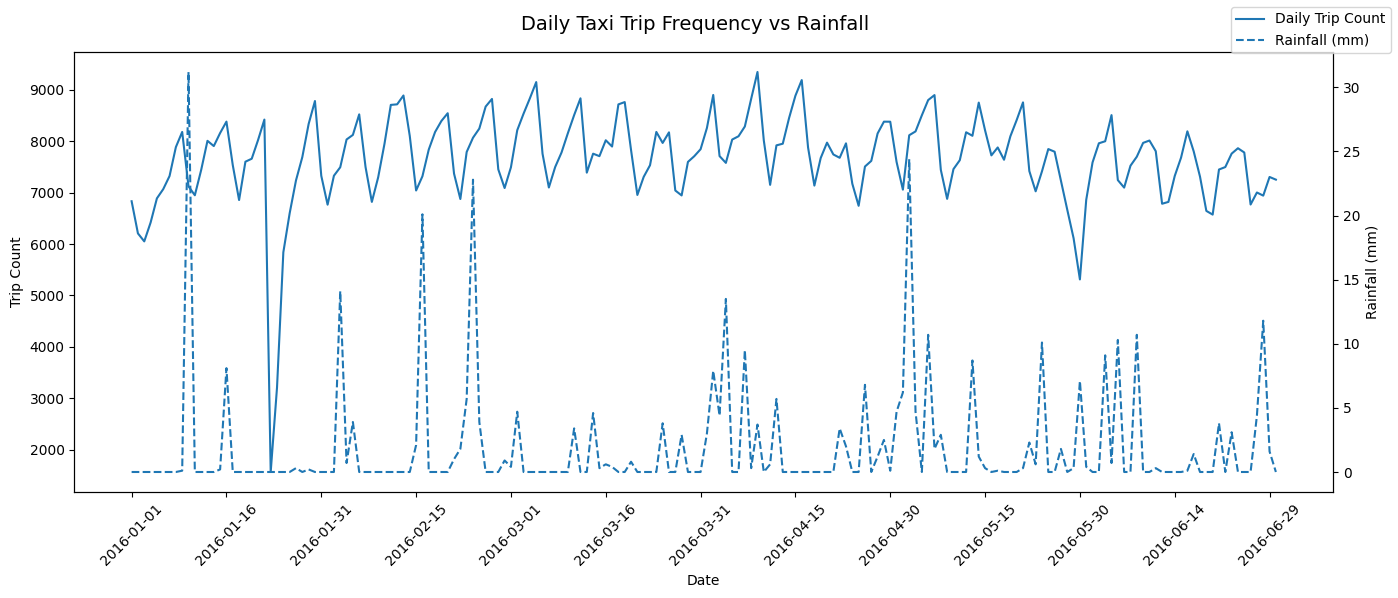

In [ ]:
daily_weather_rain = (
    df
    .groupby('date')
    .agg(
        trip_count=('id', 'count'),
        rain_mm=('rain_mm', 'mean')
    )
    .reset_index()
)

daily_weather_rain['date'] = pd.to_datetime(daily_weather_rain['date'])
daily_weather_rain.head()
fig, ax1 = plt.subplots(figsize=(14, 6))

# Trip count
ax1.plot(
    daily_weather_rain['date'],
    daily_weather_rain['trip_count'],
    label='Daily Trip Count'
)
ax1.set_ylabel('Trip Count')
ax1.set_xlabel('Date')

# Rainfall (secondary axis)
ax2 = ax1.twinx()
ax2.plot(
    daily_weather_rain['date'],
    daily_weather_rain['rain_mm'],
    linestyle='--',
    label='Rainfall (mm)'
)
ax2.set_ylabel('Rainfall (mm)')

# 15-day ticks
ax1.set_xticks(daily_weather_rain['date'][::15])
ax1.tick_params(axis='x', rotation=45)

# Title & legend
fig.suptitle('Daily Taxi Trip Frequency vs Rainfall', fontsize=14)
fig.legend(loc='upper right')

plt.tight_layout()
plt.show()


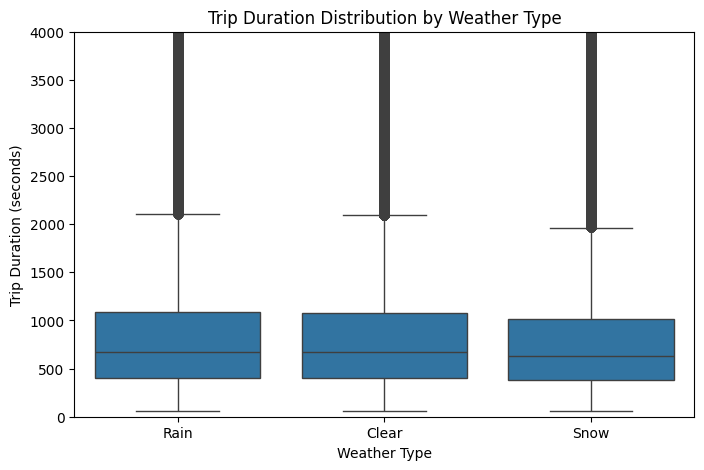

In [ ]:
df['weather_type'] = 'Clear'

df.loc[df['rain_mm'] > 0, 'weather_type'] = 'Rain'
df.loc[df['snowfall_cm'] > 0, 'weather_type'] = 'Snow'

df['weather_type'].value_counts()
duration_by_weather = (
    df
    .groupby('weather_type')
    .agg(
        trip_count=('trip_duration', 'count'),
        mean_duration=('trip_duration', 'mean'),
        median_duration=('trip_duration', 'median')
    )
    .reset_index()
)

duration_by_weather
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='weather_type',
    y='trip_duration'
)
plt.ylim(0, 4000)
plt.title('Trip Duration Distribution by Weather Type')
plt.ylabel('Trip Duration (seconds)')
plt.xlabel('Weather Type')
plt.show()


In [ ]:
print(df.columns.tolist())

# Detailed view including data types and non-null counts
print(df.info())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'distance_haversine_km', 'distance_manhattan_km', 'speed_haversine_kmh', 'speed_manhattan_kmh', 'pickup_hour', 'pickup_day', 'pickup_weekday', 'pickup_month', 'is_weekend', 'is_rush_hour', 'circuitousness', 'date', 'temp_c', 'precip_mm', 'rain_mm', 'snowfall_cm', 'wind_kmh', 'weather_type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395466 entries, 0 to 1395465
Data columns (total 29 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   id                     1395466 non-null  object        
 1   vendor_id              1395466 non-null  int64         
 2   pickup_datetime        1395466 non-null  datetime64[ns]
 3   dropoff_datetime       1395466 non-null  object        
 4   passenger_count        1395

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Assume df is your DataFrame

# Select numeric features for the model
numeric_features = [
    'vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'distance_manhattan_km',
    'pickup_hour', 'pickup_day', 'pickup_weekday', 'pickup_month',
    'is_weekend', 'is_rush_hour', 'circuitousness', 'temp_c',
    'snowfall_cm', 'wind_kmh'
]

# Define the target variable and features
X = df[numeric_features]
y = df['trip_duration']

# Add a constant to the features for the intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          trip_duration   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                 1.236e+05
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:27:49   Log-Likelihood:            -1.0396e+07
No. Observations:             1395466   AIC:                         2.079e+07
Df Residuals:                 1395448   BIC:                         2.079e+07
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -9.341e+

In [ ]:
import numpy as np
import statsmodels.api as sm

# 1. Feature Selection (Removing leakage and redundant distance/weather)
features = [
    'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'distance_manhattan_km',
    'pickup_hour', 'pickup_day', 'pickup_weekday', 'pickup_month',
    'is_weekend', 'is_rush_hour', 'circuitousness', 'temp_c',
    'rain_mm', 'snowfall_cm', 'wind_kmh'
]

X = df[features]
X = sm.add_constant(X)

y = np.log(df['trip_duration'])

# 3. Fit the clean model
clean_model = sm.OLS(y, X).fit()
print(clean_model.summary())

                            OLS Regression Results                            
Dep. Variable:          trip_duration   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                 7.190e+04
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:17:14   Log-Likelihood:            -1.1004e+06
No. Observations:             1395466   AIC:                         2.201e+06
Df Residuals:                 1395448   BIC:                         2.201e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  -298.30

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Feature Selection
features = [
    'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'distance_manhattan_km',
    'pickup_hour', 'pickup_day', 'pickup_weekday', 'pickup_month',
    'is_weekend', 'is_rush_hour', 'temp_c',
    'rain_mm', 'snowfall_cm', 'wind_kmh'
]

# 2. TAKE SAMPLE (very important for speed)
df_sample = df.sample(n=200000, random_state=42)

X = df_sample[features]
y = np.log(df_sample['trip_duration'])

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Random Forest Model (optimized)
rf_model = RandomForestRegressor(
    n_estimators=20,      # small = fast
    max_depth=4,         # control overfitting
    max_samples=100000,   # each tree uses subset
    random_state=42,
    n_jobs=-1
)

# 5. Train
rf_model.fit(X_train, y_train)

# 6. Predict
y_pred = rf_model.predict(X_test)

# 7. Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

# 8. Feature Importance (like coefficients)
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

R2 Score: 0.7468639592855284
RMSE: 0.3671147948808455

Feature Importance:
                  Feature  Importance
5   distance_manhattan_km    0.745803
6             pickup_hour    0.057540
4        dropoff_latitude    0.048019
3       dropoff_longitude    0.030542
1        pickup_longitude    0.027884
2         pickup_latitude    0.024078
8          pickup_weekday    0.015011
12                 temp_c    0.010713
15               wind_kmh    0.009719
7              pickup_day    0.008874
10             is_weekend    0.006667
13                rain_mm    0.004658
9            pickup_month    0.004420
0         passenger_count    0.002627
11           is_rush_hour    0.001836
14            snowfall_cm    0.001609


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Feature Selection
features = [
    'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'distance_haversine_km',
    'pickup_hour', 'pickup_day', 'pickup_weekday', 'pickup_month',
    'is_weekend', 'is_rush_hour', 'circuitousness', 'temp_c',
    'rain_mm', 'snowfall_cm', 'wind_kmh'
]

# 2. TAKE SAMPLE (very important for speed)
df_sample = df.sample(n=200000, random_state=42)

X = df_sample[features]
y = np.log(df_sample['trip_duration'])

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Random Forest Model (optimized)
rf_model = RandomForestRegressor(
    n_estimators=20,      # small = fast
    max_depth=15,         # control overfitting
    max_samples=100000,   # each tree uses subset
    random_state=42,
    n_jobs=-1
)

# 5. Train
rf_model.fit(X_train, y_train)

# 6. Predict
y_pred = rf_model.predict(X_test)

# 7. Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

# 8. Feature Importance (like coefficients)
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

R2 Score: 0.7665515938525299
RMSE: 0.35254970220215026

Feature Importance:
                  Feature  Importance
5   distance_haversine_km    0.751925
6             pickup_hour    0.056494
4        dropoff_latitude    0.043910
12         circuitousness    0.026037
3       dropoff_longitude    0.022598
1        pickup_longitude    0.020791
2         pickup_latitude    0.017354
8          pickup_weekday    0.014909
13                 temp_c    0.009639
16               wind_kmh    0.008687
7              pickup_day    0.007865
10             is_weekend    0.005651
14                rain_mm    0.004412
9            pickup_month    0.004042
0         passenger_count    0.002432
11           is_rush_hour    0.001810
15            snowfall_cm    0.001444


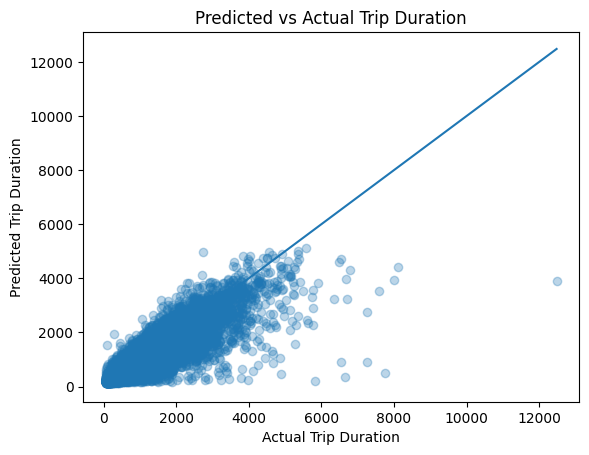

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)

# Plot
plt.figure()
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3)

min_val = min(y_test_actual.min(), y_pred_actual.min())
max_val = max(y_test_actual.max(), y_pred_actual.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Trip Duration")
plt.ylabel("Predicted Trip Duration")
plt.title("Predicted vs Actual Trip Duration")

plt.show()